[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/doxav/astromodel_proving/blob/main/analysis/05_mechanistic_decomposition.ipynb)

# Step 05 - Mechanistic decomposition of accepted cell ensembles

This notebook validates the full-scope Step 05 reviewer-response pipeline. It loads the accepted Step 04 cell-level ensemble, simulates hidden outputs with the canonical local astrocyte model, decomposes accepted fits into Kir/gap/leak and local/spatial mechanism summaries, adds the phenotype-description layer reused from the characterization notebook, and records conservative claim scope.

The implementation reuses only the missing measure vocabulary from `analysis/unified_astrocyte_K_buffering_characterization_EXECUTED_SMOKE.ipynb`: signed local/spatial flux modes, `dKs_activation_score`, available/recruited surface proxies, mode vectors, and provisional phenotype tags. It does not reuse that notebook's legacy Optuna DB loader or duplicate its ODE. Step 05 can identify candidate mechanism regimes or compensation manifolds, but predictive and perturbation support remains pending until Step 06.

## How to use each section

- **Accepted ensemble inventory**: use to confirm Step 04 cell/candidate/region coverage before interpreting mechanisms.
- **Candidate-sweep flux decomposition table**: use as the primary hidden-current and K_o decomposition evidence for accepted cell fits.
- **Protocol and K bath audit**: checks that six-current protocol context is preserved.
- **Mechanism-space clustering**: use as a candidate-regime screen in effective/mechanism space, not by raw parameters alone.
- **Flux decomposition for representative candidates**: use for interpretable examples and figures.
- **Compensation-vs-separated-mode interpolation diagnostics**: use to distinguish connected compensation from separated candidate modes.
- **Bootstrap stability table**: use to judge whether cluster labels are stable enough for reviewer-facing language.
- **DH/VH and condition occupancy table**: use as population-level association evidence, not paired pharmacology evidence.
- **Windowed phenotype-description layer**: use to inspect provisional local/spatial mechanism labels over time windows.
- **Phenotype counts by region, condition, and window**: use as descriptive phenotype occupancy evidence.
- **Legacy source mechanism/function mapping**: use as source-scoped FV-to-FK mapping for top legacy Optuna trials.
- **Legacy EF and sigmoid category counts**: use for baseline K_o EF and sigmoid-state categories that feed perturbation screens.
- **Explicit claim-scope table**: use as the allowed/forbidden wording gate before Step 06.
- **Post-execution scientific status**: use as the final run-status and interpretation summary for Step 05.

In [ ]:
from pathlib import Path
import os, sys, subprocess

def _running_in_colab() -> bool:
    return "COLAB_RELEASE_TAG" in os.environ or "google.colab" in sys.modules


if _running_in_colab():
    repo_url = os.environ.get("ASTROMODEL_REPO_URL", "https://github.com/doxav/astromodel_proving.git")
    repo_branch = os.environ.get("ASTROMODEL_REPO_BRANCH", "main")
    project_root = Path("/content") / "astromodel_proving"
    if not project_root.exists():
        subprocess.run(["git", "clone", "--depth", "1", "--branch", repo_branch, repo_url, str(project_root)], check=True)
    os.chdir(project_root)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    raw_project_root = os.environ.get("ASTROMODEL_PROJECT_ROOT")
    if raw_project_root:
        project_root = Path(raw_project_root).expanduser().resolve()
    else:
        current = Path.cwd().resolve()
        project_root = next((p for p in [current, *current.parents] if (p / "src").exists()), current)
    os.chdir(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

Project root: /home/xav/code/astromodel_proving


In [2]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt

from src.step05_mechanistic_decomposition import Step05Config, run_step05_mechanistic_decomposition


def _env_int(name: str, default: int) -> int:
    return int(os.environ.get(name, str(default)))


def _env_optional_int(name: str) -> int | None:
    raw = os.environ.get(name)
    return None if raw in {None, "", "none", "None"} else int(raw)


config = Step05Config(
    max_candidates=None,
    time_points=_env_int("ASTROMODEL_STEP05_TIME_POINTS", 120),
    bootstrap_iterations=_env_int("ASTROMODEL_STEP05_BOOTSTRAP_ITERATIONS", 8),
    random_seed=13,
    min_candidates_for_multicluster=6,
    min_cells_for_multicluster=3,
    min_cells_per_cluster=2,
    proxy_failure_downgrade_fraction=0.5,
    run_legacy_mapping=True,
    legacy_top_n_per_db=_env_int("ASTROMODEL_STEP05_LEGACY_TOP_N_PER_DB", 300),
    legacy_max_configs=_env_optional_int("ASTROMODEL_STEP05_LEGACY_MAX_CONFIGS"),
    write_outputs=True,
)
result = run_step05_mechanistic_decomposition(project_root, config)
out_dir = project_root / "outputs" / "mechanisms"
legacy_out_dir = project_root / "outputs" / "legacy_mechanisms"
print(json.dumps(result["analysis_summary"], indent=2))
print("legacy outputs:", sorted(legacy_out_dir.glob("*.csv")))


{
  "step_name": "Step 05 \u2014 Mechanistic decomposition of accepted cell ensembles",
  "input_source": "outputs/cell_fits/accepted_cell_ensembles.csv",
  "config": {
    "step04_source_path": null,
    "max_candidates": null,
    "time_points": 120,
    "t_final_ms": 50000.0,
    "n_clusters": 3,
    "bootstrap_iterations": 8,
    "random_seed": 13,
    "max_representatives": 3,
    "interpolation_points": 5,
    "small_stratum_min_cells": 3,
    "min_candidates_for_multicluster": 6,
    "min_cells_for_multicluster": 3,
    "min_cells_per_cluster": 2,
    "proxy_failure_downgrade_fraction": 0.5,
    "run_legacy_mapping": true,
    "legacy_top_n_per_db": 300,
    "legacy_max_configs": null,
    "legacy_min_rows_per_efficiency_stratum": 10,
    "write_outputs": true
  },
  "n_input_candidates": 353,
  "n_candidate_sweep_rows": 2118,
  "n_windowed_mechanism_rows": 8416,
  "n_phenotype_tag_rows": 353,
  "n_successful_sweep_simulations": 2104,
  "n_mechanism_clusters": 3,
  "n_independen

## 1. Accepted ensemble inventory

In [3]:
clusters = result["mechanism_clusters"]
flux = result["accepted_fit_mechanisms"]
inventory = clusters.groupby(["region", "condition"], as_index=False).agg(
    n_cells=("file_id", "nunique"),
    n_candidates=("candidate_id", "nunique"),
    n_clusters=("mechanism_cluster", "nunique"),
)
inventory

,region,condition,n_cells,n_candidates,n_clusters
0,DH,CONTROL,7,83,2
1,DH,MFA,3,23,2
2,DH,MFA_BA,6,46,3
3,VH,MFA,6,88,2
4,VH,MFA_BA,7,113,3


## 2. Candidate-sweep flux decomposition table

In [4]:
flux_cols = [
    "file_id", "region", "condition", "candidate_id", "sweep", "current_na", "simulation_status",
    "I_Kir_integral", "I_kgap_integral", "I_leak_integral", "gap_to_kir_integral_ratio",
    "gap_fraction", "kir_fraction", "leak_fraction", "K_o_peak", "K_o_recovery_error", "proxy_validity_class",
]
flux[flux_cols].head(12)

,file_id,region,condition,candidate_id,sweep,current_na,simulation_status,I_Kir_integral,I_kgap_integral,I_leak_integral,gap_to_kir_integral_ratio,gap_fraction,kir_fraction,leak_fraction,K_o_peak,K_o_recovery_error,proxy_validity_class
0,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_09,1,50,ok,1995.323144,2014.897057,19.009747,1.009810,0.500070,0.495212,0.004718,6.398107,0.000395,weak
1,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_09,2,75,ok,2839.156776,2852.335526,12.425292,1.004642,0.500066,0.497756,0.002178,7.227007,0.000395,weak
2,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_09,3,100,ok,3622.086963,3628.832680,5.994078,1.001862,0.500052,0.499122,0.000826,8.195851,0.000395,weak
3,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_09,4,125,ok,4507.594480,4506.915909,2.147008,0.999849,0.499843,0.499919,0.000238,9.494471,0.000395,weak
4,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_09,5,150,ok,4872.287369,4868.515537,4.505087,0.999226,0.499575,0.499962,0.000462,10.093883,0.000395,weak
5,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_09,6,175,ok,5088.558139,5082.940325,6.364013,0.998896,0.499411,0.499963,0.000625,10.493582,0.000395,weak
6,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_07,1,50,ok,85.832695,102.320206,16.415536,1.192089,0.500176,0.419579,0.080245,6.399869,0.000008,failed
7,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_07,2,75,ok,119.184584,129.771028,10.485984,1.088824,0.500194,0.459389,0.040418,7.229818,0.000010,failed
8,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_07,3,100,ok,153.670901,158.163896,4.362380,1.029238,0.500207,0.485997,0.013796,8.199765,0.000013,failed
9,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_07,4,125,ok,194.044361,191.413351,2.797587,0.986441,0.493009,0.499785,0.007206,9.499704,0.000016,failed


## 2b. Protocol and K bath audit

Step 05 must not collapse the six current protocol into repeated 100 nA bath-drive simulations. The model already knows the historical current-specific bath values; Step 05 only applies explicit per-sweep/per-current/affine/gain overrides when they are present.


In [5]:
protocol_cols = [
    "candidate_id",
    "current_na",
    "sweep",
    "K_bath_middle_used",
    "K_bath_override_mode",
    "stim_window_start_s",
    "stim_window_end_s",
    "K_o_peak",
    "K_o_recovery_error",
]
protocol_audit = flux[protocol_cols].sort_values(["candidate_id", "current_na"])
protocol_summary = flux.groupby("candidate_id", as_index=False).agg(
    n_currents=("current_na", "nunique"),
    n_unique_kbath=("K_bath_middle_used", "nunique"),
    min_kbath=("K_bath_middle_used", "min"),
    max_kbath=("K_bath_middle_used", "max"),
    override_modes=("K_bath_override_mode", lambda s: ";".join(sorted(set(map(str, s))))),
)
protocol_summary


,candidate_id,n_currents,n_unique_kbath,min_kbath,max_kbath,override_modes
0,1_DH_1_CONTROL__cand_01,6,6,6.4,10.5,historical_current_kbath_scaled_by_gain
1,1_DH_1_CONTROL__cand_02,6,6,6.4,10.5,historical_current_kbath_scaled_by_gain
2,1_DH_1_CONTROL__cand_03,6,6,6.4,10.5,historical_current_kbath_scaled_by_gain
3,1_DH_1_CONTROL__cand_04,6,6,6.4,10.5,historical_current_kbath_scaled_by_gain
4,1_DH_1_CONTROL__cand_05,6,6,6.4,10.5,historical_current_kbath_scaled_by_gain
...,...,...,...,...,...,...
348,VH_7_OG_MFA__cand_09,6,6,6.4,10.5,historical_current_kbath_scaled_by_gain
349,VH_7_OG_MFA__cand_10,6,6,6.4,10.5,historical_current_kbath_scaled_by_gain
350,VH_7_OG_MFA__cand_11,6,6,6.4,10.5,historical_current_kbath_scaled_by_gain
351,VH_7_OG_MFA__cand_12,6,6,6.4,10.5,historical_current_kbath_scaled_by_gain


## 3. Mechanism-space clustering

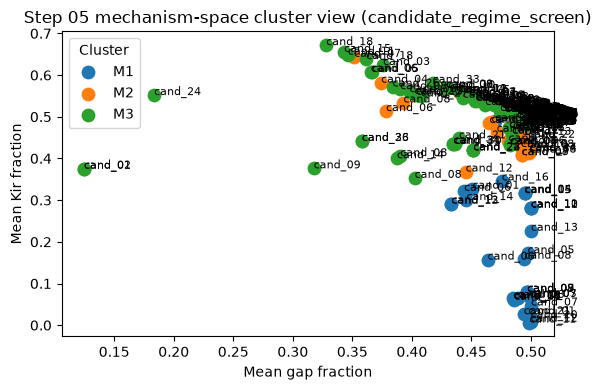

In [6]:
cluster_evidence = clusters[[
    "file_id", "candidate_id", "mechanism_cluster", "cluster_evidence_status",
    "cluster_evidence_reason", "cluster_claim_scope", "proxy_validity_status",
]].drop_duplicates()
cluster_evidence

fig, ax = plt.subplots(figsize=(6, 4))
for label, sub in clusters.groupby("mechanism_cluster"):
    ax.scatter(sub["gap_fraction_mean"], sub["kir_fraction_mean"], s=80, label=label)
for _, row in clusters.iterrows():
    ax.annotate(str(row["candidate_id"]).split("__")[-1], (row["gap_fraction_mean"], row["kir_fraction_mean"]), fontsize=8)
ax.set_xlabel("Mean gap fraction")
ax.set_ylabel("Mean Kir fraction")
evidence_status = str(clusters["cluster_evidence_status"].iloc[0]) if "cluster_evidence_status" in clusters else "unknown"
ax.set_title(f"Step 05 mechanism-space cluster view ({evidence_status})")
ax.legend(title="Cluster")
fig.tight_layout()
plt.show()


## 4. Flux decomposition for representative candidates

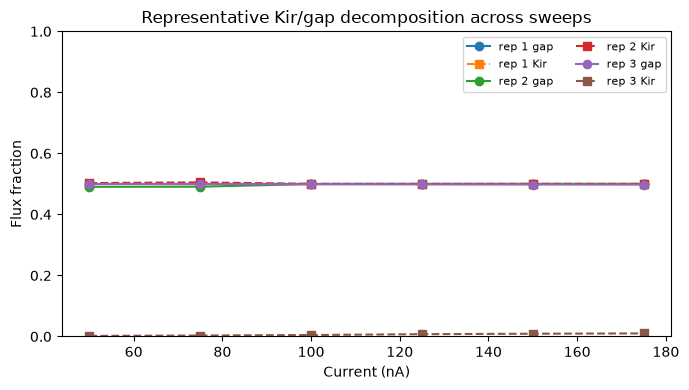

,representative_rank,file_id,condition,mechanism_cluster,dominant_mechanism,claim_scope
0,1,3_DH_2_CONTROL,CONTROL,M3,Mixed,mechanism_flux_decomposition_available_proxy_u...
1,2,VH_5_MFA_BA,MFA_BA,M1,Mixed,candidate_mechanism_regime_pending_step06_vali...
2,3,VH_4_MFA_BA,MFA_BA,M1,Mixed,candidate_mechanism_regime_pending_step06_vali...


In [7]:
reps = result["representatives"]
rep_flux = flux.merge(reps[["file_id", "candidate_id", "representative_rank"]], on=["file_id", "candidate_id"], how="inner")
fig, ax = plt.subplots(figsize=(7, 4))
for (rank, candidate_id), sub in rep_flux.groupby(["representative_rank", "candidate_id"]):
    sub = sub.sort_values("current_na")
    ax.plot(sub["current_na"], sub["gap_fraction"], marker="o", label=f"rep {rank} gap")
    ax.plot(sub["current_na"], sub["kir_fraction"], marker="s", linestyle="--", label=f"rep {rank} Kir")
ax.set_xlabel("Current (nA)")
ax.set_ylabel("Flux fraction")
ax.set_ylim(0, 1)
ax.set_title("Representative Kir/gap decomposition across sweeps")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()
reps[["representative_rank", "file_id", "condition", "mechanism_cluster", "dominant_mechanism", "claim_scope"]]

## 5. Compensation-vs-separated-mode interpolation diagnostics

In [8]:
geometry = result["geometry_classification"]
geometry[["cluster_a", "cluster_b", "geometry_screen_type", "interpolation_status", "geometry_classification", "validation_status"]]


,cluster_a,cluster_b,geometry_screen_type,interpolation_status,geometry_classification,validation_status
0,M1,M2,proxy_recovery_error_screen_not_simulated,effective_space_screened,compensation_manifold,pending_step06
1,M1,M3,proxy_recovery_error_screen_not_simulated,effective_space_screened,compensation_manifold,pending_step06
2,M2,M3,proxy_recovery_error_screen_not_simulated,effective_space_screened,compensation_manifold,pending_step06


## 6. Bootstrap stability table

In [9]:
stability = result["bootstrap_cluster_stability"]
stability


,bootstrap_iteration,n_cells,n_candidates,coassignment_stability,stability_status,stability_reason
0,1,18,319,0.995111,stable,cell_level_resampling_against_original_centers
1,2,21,366,1.000000,stable,cell_level_resampling_against_original_centers
2,3,20,365,0.989402,stable,cell_level_resampling_against_original_centers
3,4,18,431,0.995705,stable,cell_level_resampling_against_original_centers
4,5,19,265,1.000000,stable,cell_level_resampling_against_original_centers
5,6,19,384,0.990372,stable,cell_level_resampling_against_original_centers
6,7,18,318,0.980239,stable,cell_level_resampling_against_original_centers
7,8,19,363,0.984521,stable,cell_level_resampling_against_original_centers


## 7. DH/VH and condition occupancy table

In [10]:
enrichment = result["region_mechanism_enrichment"]
enrichment.sort_values(["region", "condition", "mechanism_cluster"])

,region,condition,mechanism_cluster,n_candidates,n_cells,total_candidates,total_cells,candidate_fraction,small_stratum_flag,interpretation_scope
0,DH,CONTROL,M2,51,7,83,14,0.614458,False,population_level_cell_association_not_phenotyp...
1,DH,CONTROL,M3,32,7,83,14,0.385542,False,population_level_cell_association_not_phenotyp...
2,DH,MFA,M2,11,2,23,5,0.478261,False,population_level_cell_association_not_phenotyp...
3,DH,MFA,M3,12,3,23,5,0.521739,False,population_level_cell_association_not_phenotyp...
4,DH,MFA_BA,M1,1,1,46,10,0.021739,False,population_level_cell_association_not_phenotyp...
5,DH,MFA_BA,M2,15,4,46,10,0.326087,False,population_level_cell_association_not_phenotyp...
6,DH,MFA_BA,M3,30,5,46,10,0.652174,False,population_level_cell_association_not_phenotyp...
7,VH,MFA,M2,61,6,88,11,0.693182,False,population_level_cell_association_not_phenotyp...
8,VH,MFA,M3,27,5,88,11,0.306818,False,population_level_cell_association_not_phenotyp...
9,VH,MFA_BA,M1,34,5,113,17,0.300885,False,population_level_cell_association_not_phenotyp...


## 8. Windowed phenotype-description layer

The table below is descriptive and provisional. It uses accepted Step 04 ensembles and the canonical simulator, then adds the characterization notebook's missing local/spatial and recruitment measures. These tags do not become phenotype claims unless Step 06 supports prediction and perturbation robustness.

In [11]:
measure_registry = result["measure_registry_status"]
windowed = result["accepted_fit_mechanisms_windowed"]
phenotypes = result["buffering_phenotype_tags"]
mode_vectors = result["M_mode_vector_by_configuration"]

display(measure_registry)
display(phenotypes.head(20))
display(mode_vectors.head(12))

,measure_family,measure,status,rationale
0,state reconstruction,"Vm, K_o, DK_a, DK_t, K_s, currents",primary,Hidden-state reconstruction is retained for me...
1,signed flux budget,"local load, spatial export, bath source/sink",primary,Signed local/spatial budgets distinguish local...
2,mechanistic mode,D_F and D_I_elec with finite dominance margin,primary,Continuous local/spatial axes are primary; lab...
3,recruitment,dKs_activation_score,primary,Current-weighted recruitment is more mechanist...
4,effective gap mapping,P_gap_eff = d * pk,primary,Raw d and pk remain structurally confounded; t...
5,available surface,alpha2 = gamma_s_eff,primary,Interpreted as available spatial transfer surf...
6,recruited surface,alpha2 * dKs_activation_score,primary,Combines available capacity with dynamic recru...
7,isopotentiality proxy,1 / (1 + r_model),secondary,Reduced-model analogue because the ODE has no ...
8,pump proxy,K_o recovery and undershoot summaries,secondary,"Observable recovery descriptors, not literal N..."
9,deprecated,raw d as anatomical syncytium size,deprecated,"Superseded by P_gap_eff, available surface, an..."


,file_id,region,condition,candidate_id,buffering_phenotype,phenotype_window_scope,phenotype_specificity_score,dominant_signed_flux_mode,dKs_activation_score_mean,long_range_distribution_fraction_mean,voltage_coupling_score_mean,kir_current_score_mean,phenotype_claim_scope
0,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_01,low_recruitment_local_storage,M_tot,1.000000,STRICTLY_LOCAL,4.145198e-92,2.349894e-93,0.365459,0.562708,provisional_accepted_ensemble_tag_pending_step...
1,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_02,low_recruitment_local_storage,M_tot,1.000000,STRICTLY_LOCAL,4.145198e-92,2.349894e-93,0.365459,0.562708,provisional_accepted_ensemble_tag_pending_step...
2,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_03,mixed_local_spatial_buffering,M_tot,1.000000,STRICTLY_LOCAL,3.840785e-01,1.623915e-02,0.367431,0.631155,provisional_accepted_ensemble_tag_pending_step...
3,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_04,available_surface_voltage_coupled_but_ionic_re...,M_tot,1.000000,BALANCED_OR_WEAK,9.859677e-305,6.779235e-306,0.487955,0.511784,provisional_accepted_ensemble_tag_pending_step...
4,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_05,mixed_local_spatial_buffering,M_tot,1.000000,BALANCED_OR_WEAK,2.237473e-01,3.984150e-01,0.472401,0.526783,provisional_accepted_ensemble_tag_pending_step...
5,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_06,mixed_local_spatial_buffering,M_tot,1.000000,STRICTLY_LOCAL,2.293984e-01,9.611196e-03,0.367351,0.560125,provisional_accepted_ensemble_tag_pending_step...
6,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_07,mixed_local_spatial_buffering,M_tot,1.000000,STRICTLY_LOCAL,4.685128e-01,1.279828e-02,0.337112,0.575891,provisional_accepted_ensemble_tag_pending_step...
7,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_08,low_recruitment_local_storage,M_tot,1.000000,STRICTLY_LOCAL,4.524668e-77,2.291771e-79,0.299877,0.481687,provisional_accepted_ensemble_tag_pending_step...
8,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_09,available_surface_voltage_coupled_but_ionic_re...,M_tot,1.000000,BALANCED_OR_WEAK,5.633061e-04,4.232319e-01,0.489924,0.504331,provisional_accepted_ensemble_tag_pending_step...
9,1_DH_2_CONTROL,DH,CONTROL,1_DH_2_CONTROL__cand_02,kir_dominant_local_buffering,M_tot,0.666667,STRICTLY_LOCAL,3.067974e-01,3.354425e-01,0.246414,0.753242,provisional_accepted_ensemble_tag_pending_step...


,file_id,region,condition,candidate_id,sweep,current_na,mode_M0,mode_M_decay,mode_M_rise,mode_M_tot,buffering_phenotype,phenotype_claim_scope
0,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_01,1,50,MIXED_LOCAL,MIXED_LOCAL,BALANCED_OR_WEAK,STRICTLY_LOCAL,low_recruitment_local_storage,provisional_accepted_ensemble_tag_pending_step...
1,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_01,2,75,MIXED_LOCAL,MIXED_LOCAL,BALANCED_OR_WEAK,STRICTLY_LOCAL,low_recruitment_local_storage,provisional_accepted_ensemble_tag_pending_step...
2,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_01,3,100,MIXED_LOCAL,MIXED_LOCAL,BALANCED_OR_WEAK,STRICTLY_LOCAL,low_recruitment_local_storage,provisional_accepted_ensemble_tag_pending_step...
3,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_01,4,125,MIXED_LOCAL,MIXED_LOCAL,BALANCED_OR_WEAK,STRICTLY_LOCAL,low_recruitment_local_storage,provisional_accepted_ensemble_tag_pending_step...
4,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_01,5,150,MIXED_LOCAL,MIXED_LOCAL,BALANCED_OR_WEAK,STRICTLY_LOCAL,low_recruitment_local_storage,provisional_accepted_ensemble_tag_pending_step...
5,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_01,6,175,MIXED_LOCAL,BALANCED_OR_WEAK,BALANCED_OR_WEAK,STRICTLY_LOCAL,low_recruitment_local_storage,provisional_accepted_ensemble_tag_pending_step...
6,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_02,1,50,MIXED_LOCAL,MIXED_LOCAL,BALANCED_OR_WEAK,STRICTLY_LOCAL,low_recruitment_local_storage,provisional_accepted_ensemble_tag_pending_step...
7,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_02,2,75,MIXED_LOCAL,MIXED_LOCAL,BALANCED_OR_WEAK,STRICTLY_LOCAL,low_recruitment_local_storage,provisional_accepted_ensemble_tag_pending_step...
8,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_02,3,100,MIXED_LOCAL,MIXED_LOCAL,BALANCED_OR_WEAK,STRICTLY_LOCAL,low_recruitment_local_storage,provisional_accepted_ensemble_tag_pending_step...
9,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_02,4,125,MIXED_LOCAL,MIXED_LOCAL,BALANCED_OR_WEAK,STRICTLY_LOCAL,low_recruitment_local_storage,provisional_accepted_ensemble_tag_pending_step...


## 9. Phenotype counts by region, condition, and window

In [12]:
phenotype_counts = result["phenotype_counts_by_region_condition_window"]
phenotype_counts.sort_values(["region", "condition", "window", "buffering_phenotype"]).head(40)

,region,condition,window,buffering_phenotype,n_candidate_sweeps,n_candidates,n_cells
0,DH,CONTROL,M0,available_surface_voltage_coupled_but_ionic_re...,210,36,7
1,DH,CONTROL,M0,long_range_recruited_spatial_buffering,6,1,1
2,DH,CONTROL,M0,low_recruitment_local_storage,60,10,5
3,DH,CONTROL,M0,mixed_local_spatial_buffering,216,36,6
4,DH,CONTROL,M_decay,available_surface_voltage_coupled_but_ionic_re...,186,32,7
5,DH,CONTROL,M_decay,kir_dominant_local_buffering,4,2,2
6,DH,CONTROL,M_decay,long_range_recruited_spatial_buffering,25,6,3
7,DH,CONTROL,M_decay,low_recruitment_local_storage,74,15,5
8,DH,CONTROL,M_decay,mixed_local_spatial_buffering,197,36,6
9,DH,CONTROL,M_decay,recruited_surface_gap_assisted_buffering,6,1,1


## 10. Legacy source mechanism/function mapping

This section uses top legacy Optuna configurations, not Step 04 accepted cell-specific ensembles. It computes sigmoid state categories, temporal recruitment tags, K_o EF scores, and FV-to-FK mappings for the perturbation layer.


In [13]:
legacy_categories = result["legacy_mechanism_categories"]
legacy_efficiency = result["legacy_function_efficiency_by_configuration"]
legacy_mapping = result["legacy_mechanistic_function_mapping"]

display(legacy_categories.head(30))
display(legacy_efficiency.head(30))
display(legacy_mapping.head(30))
assert {"sigmoid_state_at_stim_end_10_90", "sigmoid_state_at_sim_end_10_90", "temporal_recruitment_class", "category_id"}.issubset(legacy_categories.columns)
assert {"Ko_efficiency_score", "Ko_efficiency_quadrant"}.issubset(legacy_efficiency.columns)


,source_scope,legacy_configuration_status,legacy_selection_rule,legacy_acceptance_rule,db_name,file_id,region,condition,current_na,trial_number,...,recruited_surface_alpha2_x_A_dKs,long_range_distribution_fraction,kir_current_score,voltage_coupling_score,mechanistic_mode_signed_flux,buffering_phenotype_M_tot,gj_ionic_state_10_90,functional_n_flux_proxy_dKs_activation,functional_n_end_proxy_chi_end,category_id
0,legacy_single_current_optuna,legacy_top300_optuna_trial,top_n_by_objective,not_thresholded_top_n_first_pass,CONTROL_50nA.db,CONTROL_50nA,legacy_unassigned,CONTROL,50,2067,...,1.086950e-63,2.697113e-58,0.262730,0.371692,MIXED_LOCAL,low_recruitment_local_storage,closed_low,1.194725e-59,2.088083e-110,CONTROL|50|closed_low|closed_low|fully_closed_...
1,legacy_single_current_optuna,legacy_top300_optuna_trial,top_n_by_objective,not_thresholded_top_n_first_pass,CONTROL_50nA.db,CONTROL_50nA,legacy_unassigned,CONTROL,50,2182,...,8.932481e-60,9.766806e-55,0.359179,0.327363,BALANCED_OR_WEAK,low_recruitment_local_storage,closed_low,9.888845e-56,2.436202e-99,CONTROL|50|closed_low|closed_low|fully_closed_...
2,legacy_single_current_optuna,legacy_top300_optuna_trial,top_n_by_objective,not_thresholded_top_n_first_pass,CONTROL_50nA.db,CONTROL_50nA,legacy_unassigned,CONTROL,50,2262,...,4.788566e-95,2.633882e-90,0.433390,0.248358,STRICTLY_LOCAL,low_recruitment_local_storage,closed_low,5.051269e-91,8.743701e-138,CONTROL|50|closed_low|closed_low|fully_closed_...
3,legacy_single_current_optuna,legacy_top300_optuna_trial,top_n_by_objective,not_thresholded_top_n_first_pass,CONTROL_50nA.db,CONTROL_50nA,legacy_unassigned,CONTROL,50,2250,...,6.550737e-59,1.046583e-53,0.366450,0.337908,BALANCED_OR_WEAK,low_recruitment_local_storage,closed_low,7.377123e-55,4.609917e-100,CONTROL|50|closed_low|closed_low|fully_closed_...
4,legacy_single_current_optuna,legacy_top300_optuna_trial,top_n_by_objective,not_thresholded_top_n_first_pass,CONTROL_50nA.db,CONTROL_50nA,legacy_unassigned,CONTROL,50,2413,...,9.206823e-129,6.652819e-127,0.548899,0.000320,STRICTLY_LOCAL,low_recruitment_local_storage,closed_low,1.055156e-124,3.865520e-170,CONTROL|50|closed_low|closed_low|fully_closed_...
5,legacy_single_current_optuna,legacy_top300_optuna_trial,top_n_by_objective,not_thresholded_top_n_first_pass,CONTROL_50nA.db,CONTROL_50nA,legacy_unassigned,CONTROL,50,2482,...,9.735341e-144,3.348257e-140,0.539678,0.013062,STRICTLY_LOCAL,low_recruitment_local_storage,closed_low,5.426799e-139,1.040542e-185,CONTROL|50|closed_low|closed_low|fully_closed_...
6,legacy_single_current_optuna,legacy_top300_optuna_trial,top_n_by_objective,not_thresholded_top_n_first_pass,CONTROL_50nA.db,CONTROL_50nA,legacy_unassigned,CONTROL,50,2158,...,1.617322e-75,1.965232e-70,0.330942,0.334908,BALANCED_OR_WEAK,low_recruitment_local_storage,closed_low,1.767058e-71,3.010942e-116,CONTROL|50|closed_low|closed_low|fully_closed_...
7,legacy_single_current_optuna,legacy_top300_optuna_trial,top_n_by_objective,not_thresholded_top_n_first_pass,CONTROL_50nA.db,CONTROL_50nA,legacy_unassigned,CONTROL,50,2480,...,2.776313e-147,1.221604e-143,0.537424,0.016735,STRICTLY_LOCAL,low_recruitment_local_storage,closed_low,1.177864e-142,1.573060e-190,CONTROL|50|closed_low|closed_low|fully_closed_...
8,legacy_single_current_optuna,legacy_top300_optuna_trial,top_n_by_objective,not_thresholded_top_n_first_pass,CONTROL_50nA.db,CONTROL_50nA,legacy_unassigned,CONTROL,50,2348,...,5.966693e-75,1.228692e-69,0.360456,0.342126,BALANCED_OR_WEAK,low_recruitment_local_storage,closed_low,5.516842e-71,4.107427e-119,CONTROL|50|closed_low|closed_low|fully_closed_...
9,legacy_single_current_optuna,legacy_top300_optuna_trial,top_n_by_objective,not_thresholded_top_n_first_pass,CONTROL_50nA.db,CONTROL_50nA,legacy_unassigned,CONTROL,50,2402,...,3.722485e-133,8.585149e-130,0.540394,0.009144,STRICTLY_LOCAL,low_recruitment_local_storage,closed_low,4.218141e-129,1.496529e-180,CONTROL|50|closed_low|closed_low|fully_closed_...


,source_scope,db_name,condition,current_na,trial_number,candidate_id,Ko_baseline_mM,Ko_peak_mM,Ko_final_mM,Ko_recovery_error_mM,...,Ko_rise_over_decay_rate,Ko_efficiency_score,Ko_rise_speed_class,Ko_decay_speed_class,Ko_efficiency_quadrant,Ko_efficiency_status,Ko_rise_fast_slow_cutoff,Ko_decay_fast_slow_cutoff,Ko_efficiency_threshold_source,Ko_efficiency_threshold_interpretation
0,legacy_single_current_optuna,CONTROL_50nA.db,CONTROL,50,2067,CONTROL_50nA.db::trial_2067,5.081244,7.431297,5.225421,0.144176,...,0.680301,0.680301,slow_rise,fast_decay,slow_rise_fast_decay,defined,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
1,legacy_single_current_optuna,CONTROL_50nA.db,CONTROL,50,2182,CONTROL_50nA.db::trial_2182,5.078517,7.385864,5.216211,0.137694,...,0.756582,0.756582,slow_rise,fast_decay,slow_rise_fast_decay,defined,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
2,legacy_single_current_optuna,CONTROL_50nA.db,CONTROL,50,2262,CONTROL_50nA.db::trial_2262,5.229943,7.443722,5.272450,0.042507,...,0.868757,0.868757,slow_rise,fast_decay,slow_rise_fast_decay,defined,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
3,legacy_single_current_optuna,CONTROL_50nA.db,CONTROL,50,2250,CONTROL_50nA.db::trial_2250,5.000907,7.349912,5.194588,0.193681,...,0.642899,0.642899,slow_rise,fast_decay,slow_rise_fast_decay,defined,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
4,legacy_single_current_optuna,CONTROL_50nA.db,CONTROL,50,2413,CONTROL_50nA.db::trial_2413,5.323619,7.509949,5.368084,0.044465,...,0.886283,0.886283,fast_rise,fast_decay,fast_rise_fast_decay,defined,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
5,legacy_single_current_optuna,CONTROL_50nA.db,CONTROL,50,2482,CONTROL_50nA.db::trial_2482,5.350360,7.582398,5.361235,0.010875,...,0.957114,0.957114,fast_rise,fast_decay,fast_rise_fast_decay,defined,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
6,legacy_single_current_optuna,CONTROL_50nA.db,CONTROL,50,2158,CONTROL_50nA.db::trial_2158,5.104381,7.325637,5.219915,0.115534,...,0.759582,0.759582,slow_rise,fast_decay,slow_rise_fast_decay,defined,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
7,legacy_single_current_optuna,CONTROL_50nA.db,CONTROL,50,2480,CONTROL_50nA.db::trial_2480,5.315705,7.576941,5.339441,0.023736,...,0.932965,0.932965,fast_rise,fast_decay,fast_rise_fast_decay,defined,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
8,legacy_single_current_optuna,CONTROL_50nA.db,CONTROL,50,2348,CONTROL_50nA.db::trial_2348,5.022361,7.369279,5.231753,0.209392,...,0.551320,0.551320,slow_rise,fast_decay,slow_rise_fast_decay,defined,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...
9,legacy_single_current_optuna,CONTROL_50nA.db,CONTROL,50,2402,CONTROL_50nA.db::trial_2402,5.315528,7.543682,5.356221,0.040693,...,0.899961,0.899961,fast_rise,fast_decay,fast_rise_fast_decay,defined,1.262747,0.515837,source_scope_current_na_legacy_median,descriptive_legacy_baseline_median_no_experime...


,source_scope,db_name,condition,current_na,trial_number,candidate_id,P_gap_eff,gamma_s_eff,gki,zth,...,gap_fraction,kir_fraction,leak_fraction,Ko_peak_mM,Ko_final_mM,Ko_recovery_error_mM,Ko_rise_rate_mM_per_s,Ko_decay_rate_abs_mM_per_s,Ko_efficiency_score,Ko_efficiency_quadrant
0,legacy_single_current_optuna,CONTROL_50nA.db,CONTROL,50,2067,CONTROL_50nA.db::trial_2067,4.282360e-06,0.000091,153.293517,26.454507,...,0.499072,0.265631,0.235298,7.431297,5.225421,0.144176,0.968183,1.423169,0.680301,slow_rise_fast_decay
1,legacy_single_current_optuna,CONTROL_50nA.db,CONTROL,50,2182,CONTROL_50nA.db::trial_2182,2.349273e-06,0.000090,153.084451,25.401323,...,0.497870,0.372990,0.129140,7.385864,5.216211,0.137694,1.041376,1.376422,0.756582,slow_rise_fast_decay
2,legacy_single_current_optuna,CONTROL_50nA.db,CONTROL,50,2262,CONTROL_50nA.db::trial_2262,1.285898e-06,0.000095,144.870558,28.831453,...,0.457739,0.495596,0.046665,7.443722,5.272450,0.042507,1.189734,1.369467,0.868757,slow_rise_fast_decay
3,legacy_single_current_optuna,CONTROL_50nA.db,CONTROL,50,2250,CONTROL_50nA.db::trial_2250,2.937395e-06,0.000089,147.819710,28.854411,...,0.498565,0.410451,0.090984,7.349912,5.194588,0.193681,0.951376,1.479822,0.642899,slow_rise_fast_decay
4,legacy_single_current_optuna,CONTROL_50nA.db,CONTROL,50,2413,CONTROL_50nA.db::trial_2413,1.288556e-09,0.000087,171.043344,38.741499,...,0.000430,0.501844,0.497726,7.509949,5.368084,0.044465,1.447762,1.633521,0.886283,fast_rise_fast_decay
5,legacy_single_current_optuna,CONTROL_50nA.db,CONTROL,50,2482,CONTROL_50nA.db::trial_2482,6.021719e-08,0.000018,181.630696,42.595369,...,0.019425,0.501366,0.479209,7.582398,5.361235,0.010875,1.611542,1.683752,0.957114,fast_rise_fast_decay
6,legacy_single_current_optuna,CONTROL_50nA.db,CONTROL,50,2158,CONTROL_50nA.db::trial_2158,2.781797e-06,0.000092,152.509142,27.496828,...,0.498357,0.331802,0.169840,7.325637,5.219915,0.115534,0.995403,1.310461,0.759582,slow_rise_fast_decay
7,legacy_single_current_optuna,CONTROL_50nA.db,CONTROL,50,2480,CONTROL_50nA.db::trial_2480,8.004467e-08,0.000024,180.355015,43.492425,...,0.024310,0.501500,0.474189,7.576941,5.339441,0.023736,1.654937,1.773846,0.932965,fast_rise_fast_decay
8,legacy_single_current_optuna,CONTROL_50nA.db,CONTROL,50,2348,CONTROL_50nA.db::trial_2348,3.034141e-06,0.000108,151.573511,33.273815,...,0.498899,0.439794,0.061307,7.369279,5.231753,0.209392,0.865460,1.569796,0.551320,slow_rise_fast_decay
9,legacy_single_current_optuna,CONTROL_50nA.db,CONTROL,50,2402,CONTROL_50nA.db::trial_2402,4.159737e-08,0.000088,170.365496,39.135160,...,0.012571,0.501669,0.485759,7.543682,5.356221,0.040693,1.591473,1.768381,0.899961,fast_rise_fast_decay


## 11. Legacy EF and sigmoid category counts


In [14]:
category_counts = legacy_categories.groupby([
    "condition",
    "current_na",
    "sigmoid_state_at_stim_end_10_90",
    "sigmoid_state_at_sim_end_10_90",
    "temporal_recruitment_class",
], dropna=False).size().reset_index(name="n_configs")
eff_counts = legacy_efficiency.groupby(["condition", "current_na", "Ko_efficiency_quadrant"], dropna=False).size().reset_index(name="n_configs")
display(category_counts.sort_values(["condition", "current_na", "n_configs"], ascending=[True, True, False]).head(60))
display(eff_counts.sort_values(["condition", "current_na", "Ko_efficiency_quadrant"]))


,condition,current_na,sigmoid_state_at_stim_end_10_90,sigmoid_state_at_sim_end_10_90,temporal_recruitment_class,n_configs
2,CONTROL,50,open_high,open_high,early_sustained_open_recruitment,174
0,CONTROL,50,closed_low,closed_low,fully_closed_at_sim_end,125
1,CONTROL,50,open_high,closed_low,recruited_during_load_then_closed_by_end,1
3,CONTROL,75,closed_low,closed_low,fully_closed_at_sim_end,300
4,CONTROL,100,closed_low,closed_low,fully_closed_at_sim_end,293
6,CONTROL,100,partial_mid,closed_low,recruited_during_load_then_closed_by_end,5
5,CONTROL,100,open_high,closed_low,recruited_during_load_then_closed_by_end,1
7,CONTROL,100,partial_mid,partial_mid,intermediate_or_mixed_temporal_recruitment,1
10,CONTROL,125,open_high,open_high,early_sustained_open_recruitment,263
9,CONTROL,125,open_high,closed_low,recruited_during_load_then_closed_by_end,18


,condition,current_na,Ko_efficiency_quadrant,n_configs
0,CONTROL,50,fast_rise_fast_decay,112
1,CONTROL,50,fast_rise_slow_decay,121
2,CONTROL,50,slow_rise_fast_decay,56
3,CONTROL,50,slow_rise_slow_decay,2
4,CONTROL,50,undefined,9
5,CONTROL,75,fast_rise_fast_decay,271
6,CONTROL,75,slow_rise_fast_decay,29
7,CONTROL,100,fast_rise_fast_decay,299
8,CONTROL,100,slow_rise_slow_decay,1
9,CONTROL,125,fast_rise_fast_decay,231


## 12. Explicit claim-scope table

In [15]:
claims = result["claim_scope_table"]
claims[[
    "claim_topic", "allowed_pre_step06_claim", "forbidden_pre_step06_claim",
    "required_next_step", "n_clusters", "n_independent_cells", "n_candidates",
    "cluster_evidence_status", "proxy_validity_status",
]]


,claim_topic,allowed_pre_step06_claim,forbidden_pre_step06_claim,required_next_step,n_clusters,n_independent_cells,n_candidates,cluster_evidence_status,proxy_validity_status
0,mechanism_diversity,accepted_compensation_or_mixed_mechanism_struc...,candidate_degenerate_regimes,Step 06 predictive and perturbation validation,3,29,353,candidate_regime_screen,proxy_not_failed_majority
1,region_enrichment,population_level_cell_association_not_phenotyp...,paired_pharmacology_or_animal_level_phenotype,larger stratified validation and Step 06 robus...,3,29,353,candidate_regime_screen,proxy_not_failed_majority


In [16]:
assert (flux["simulation_status"] == "ok").any()
assert {"region", "condition", "mechanism_cluster", "cluster_evidence_status"}.issubset(clusters.columns)
assert "K_bath_middle_used" in flux.columns
assert flux.groupby("candidate_id")["K_bath_middle_used"].nunique().min() > 1
assert not windowed.empty
assert windowed["dKs_activation_score"].between(0.0, 1.0).all()
assert "buffering_phenotype" in phenotypes.columns
assert claims["forbidden_pre_step06_claim"].str.contains("candidate_degenerate_regimes").any()
assert not claims["allowed_pre_step06_claim"].str.contains("candidate_degenerate_regimes").any()
if clusters["cluster_evidence_status"].eq("insufficient_evidence").any():
    assert claims.loc[claims["claim_topic"] == "mechanism_diversity", "allowed_pre_step06_claim"].iloc[0] == "insufficient_evidence_for_candidate_mechanism_regimes"
print(f"Step 05 full-scope notebook validated and outputs saved under {out_dir}")


Step 05 full-scope notebook validated and outputs saved under /home/xav/code/astromodel_proving/outputs/mechanisms


## Post-execution scientific status

Executed status for reviewer response: Step 05 retains the Step 04 accepted-ensemble hidden-current and phenotype decomposition and adds a separate legacy-source mechanism/function mapping. The legacy layer computes K_o EF scores, descriptive EF quadrants, sigmoid open/partial/closed states at stimulation/end, temporal recruitment tags, and FV-to-FK mapping for top legacy Optuna configurations. These outputs support R5 mechanism-pathway exploration and feed Step 06 perturbation screens. They remain model-derived mechanistic screens, not biological degeneracy proof.
